In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

from scipy.linalg import svd
from numpy.linalg import pinv

plt.rcParams['figure.figsize'] = [16,8]

In [2]:
A = np.array([[1,2],
              [3,4],
              [5,6]])

print("Macierz A:")
print(A)

U, s, VT = svd(A)

print("\nMacierz U:")
print(U)

print("\nWartości singularne:")
print(s)

print("\nMacierz VT:")
print(VT)

Macierz A:
[[1 2]
 [3 4]
 [5 6]]

Macierz U:
[[-0.2298477   0.88346102  0.40824829]
 [-0.52474482  0.24078249 -0.81649658]
 [-0.81964194 -0.40189603  0.40824829]]

Wartości singularne:
[9.52551809 0.51430058]

Macierz VT:
[[-0.61962948 -0.78489445]
 [-0.78489445  0.61962948]]


In [3]:
A = np.array([
    [0.1,0.2],
    [0.3,0.4],
    [0.5,0.6],
    [0.7,0.8]
])

print("Macierz A:")
print(A)

B = pinv(A)

print("\nPseudoodwrotność A:")
print(B)

Macierz A:
[[0.1 0.2]
 [0.3 0.4]
 [0.5 0.6]
 [0.7 0.8]]

Pseudoodwrotność A:
[[-1.00000000e+01 -5.00000000e+00  1.28757642e-14  5.00000000e+00]
 [ 8.50000000e+00  4.50000000e+00  5.00000000e-01 -3.50000000e+00]]


In [4]:
A = np.array([
 [0.1,0.2],
 [0.3,0.4],
 [0.5,0.6],
 [0.7,0.8]
])

print("Macierz A:")
print(A)

U, s, VT = np.linalg.svd(A)

# inverse singular values
d = 1.0/s

D = np.zeros(A.shape)

D[:A.shape[1], :A.shape[1]] = np.diag(d)

B = VT.T.dot(D.T).dot(U.T)

print("\nPseudoodwrotność (SVD):")
print(B)

Macierz A:
[[0.1 0.2]
 [0.3 0.4]
 [0.5 0.6]
 [0.7 0.8]]

Pseudoodwrotność (SVD):
[[-1.00000000e+01 -5.00000000e+00  1.28565458e-14  5.00000000e+00]
 [ 8.50000000e+00  4.50000000e+00  5.00000000e-01 -3.50000000e+00]]


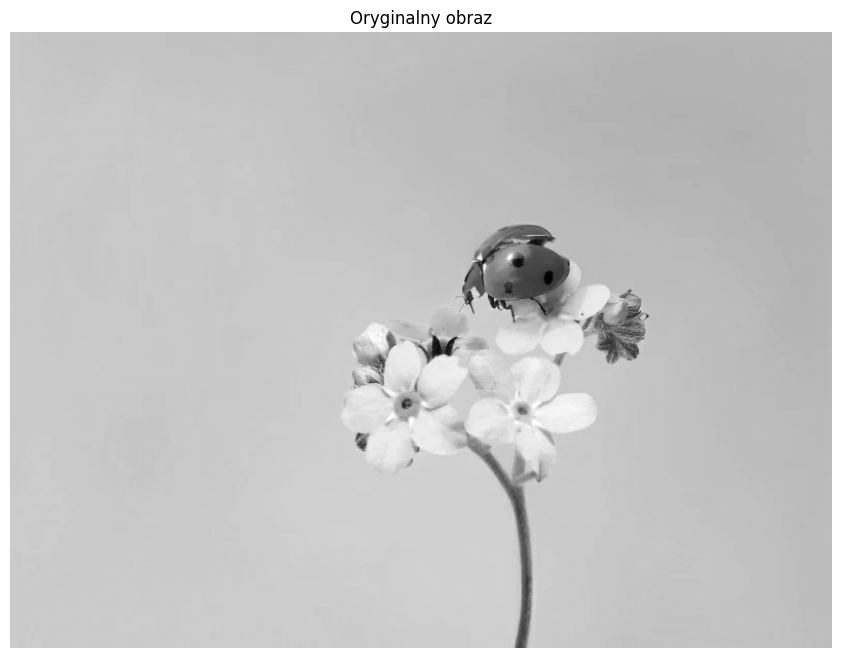

In [5]:
A = imread('10.webp')

# RGB to grayscale conversion
X = np.mean(A,-1)

plt.imshow(X)
plt.set_cmap('gray')
plt.axis('off')
plt.title("Oryginalny obraz")
plt.show()

In [6]:
U, S, VT = np.linalg.svd(X, full_matrices=False)

print("Liczba wartości singularnych:")
print(S.shape)

S_matrix = np.diag(S)

Liczba wartości singularnych:
(600,)


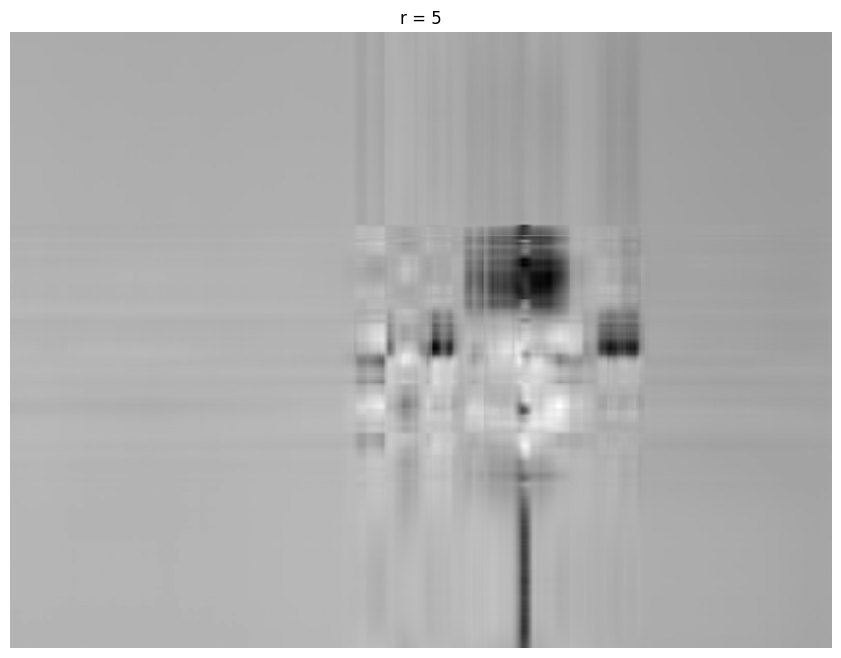

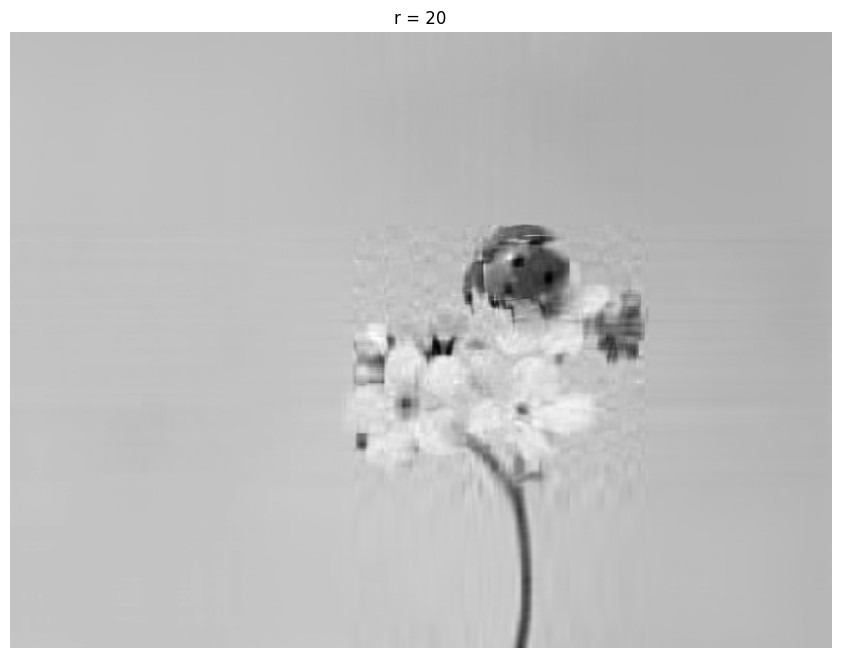

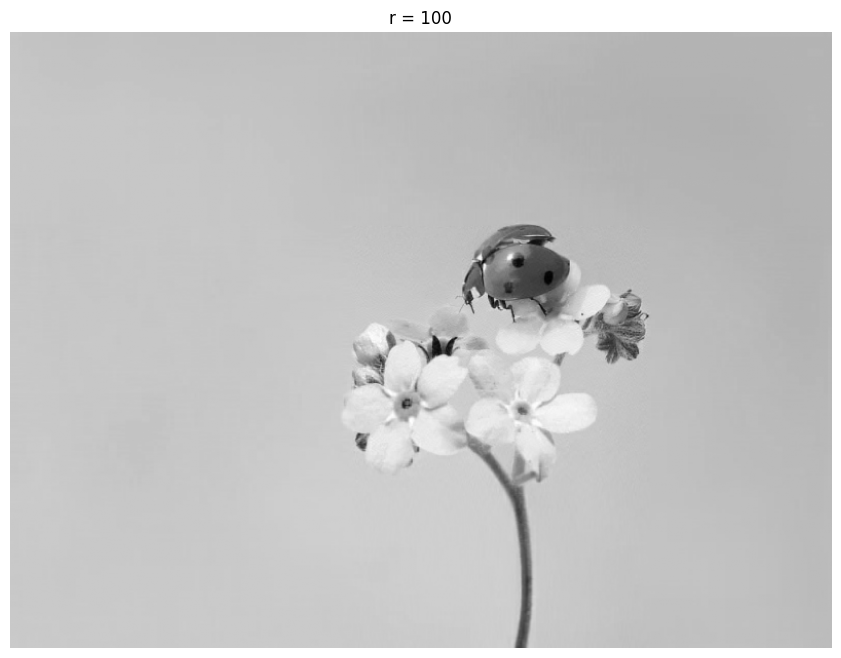

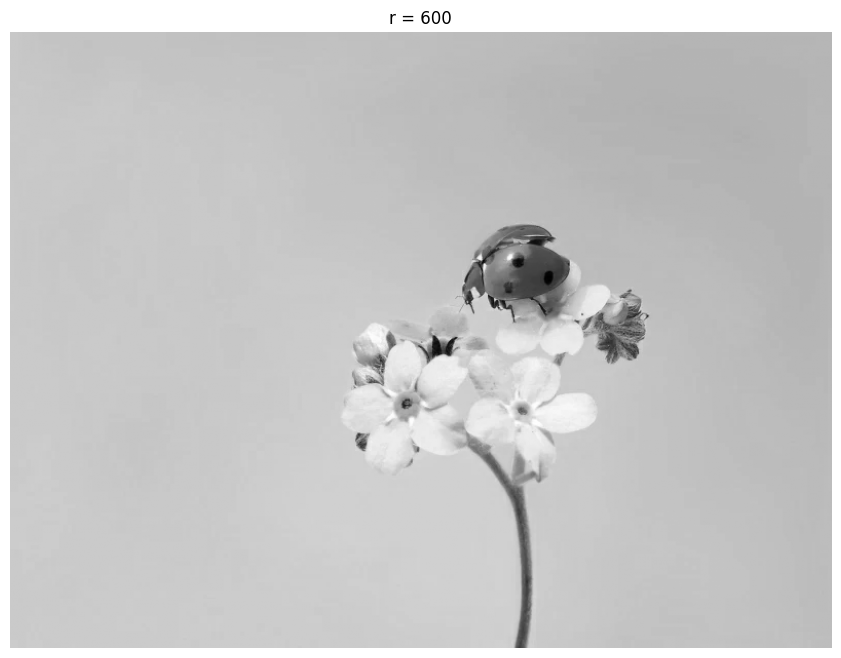

In [7]:
j = 0

for r in (5,20,100,600):

    Xapprox = U[:,:r] @ S_matrix[:r,:r] @ VT[:r,:]

    plt.figure(j+1)
    j += 1

    plt.imshow(Xapprox)
    plt.set_cmap('gray')
    plt.axis('off')
    plt.title("r = " + str(r))

    plt.show()

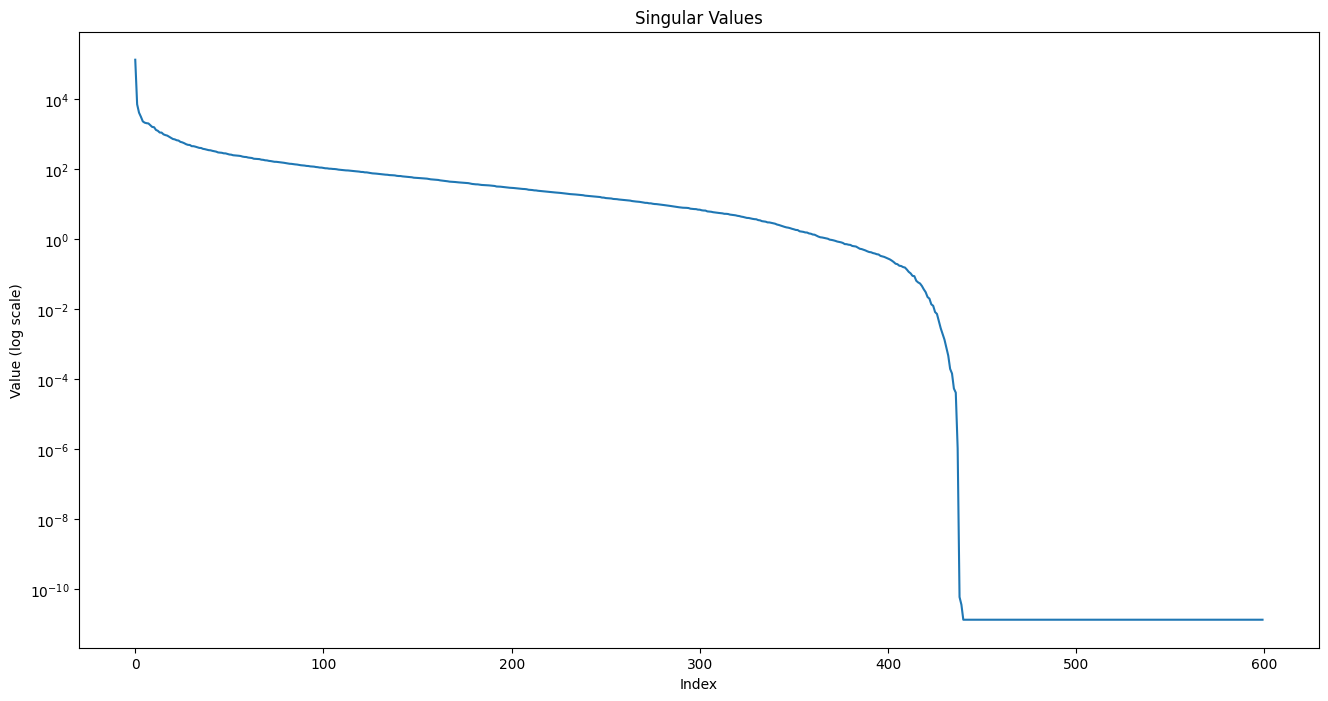

In [8]:
plt.figure()

plt.semilogy(S)

plt.title("Singular Values")
plt.xlabel("Index")
plt.ylabel("Value (log scale)")

plt.show()

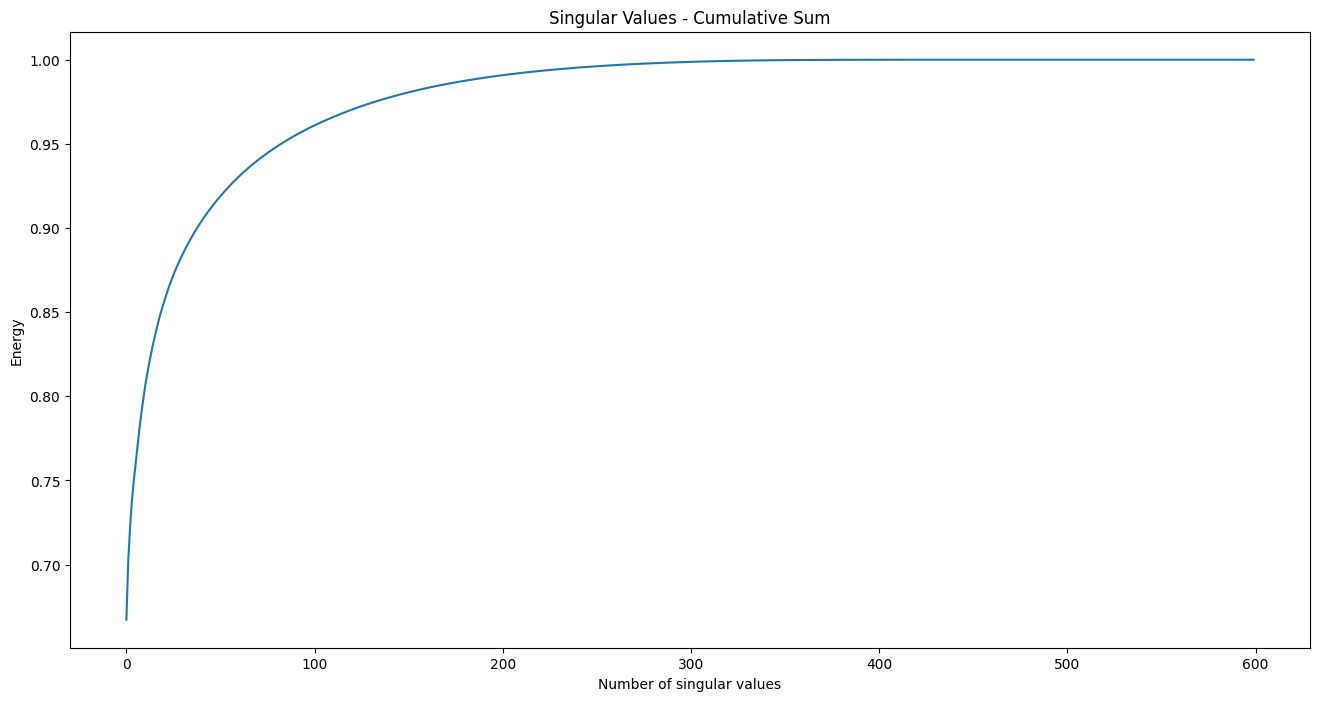

In [9]:
cumulative = np.cumsum(S) / np.sum(S)

plt.figure()

plt.plot(cumulative)

plt.title("Singular Values - Cumulative Sum")
plt.xlabel("Number of singular values")
plt.ylabel("Energy")

plt.show()

In [10]:
threshold = 0.9

r90 = np.argmax(cumulative >= threshold) + 1

print("Liczba wartości singularnych potrzebna do zachowania 90% informacji:")
print(r90)

Liczba wartości singularnych potrzebna do zachowania 90% informacji:
39


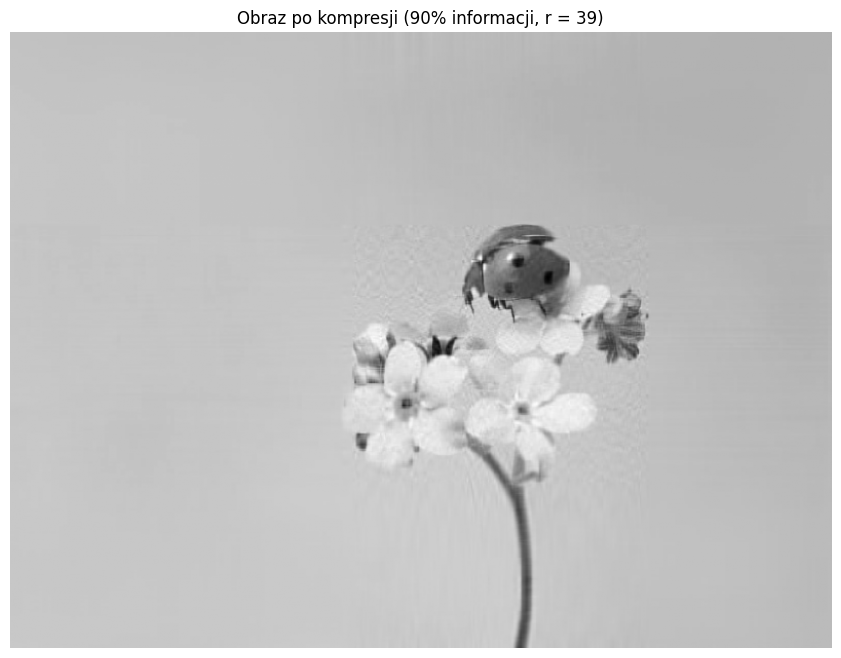

In [11]:
r = 39

Xapprox_90 = U[:,:r] @ S_matrix[:r,:r] @ VT[:r,:]

plt.figure()

plt.imshow(Xapprox_90)
plt.set_cmap('gray')
plt.axis('off')

plt.title("Obraz po kompresji (90% informacji, r = 39)")

plt.show()